# 03 — Baseline Modelling

**Competition:** A Cloned Airbnb Booking Prediction Competition — K353  
**Course:** COMP 468 — Abdullah Gül University

## Goal
Build a clean, **leakage-proof** baseline pipeline using only **course-allowed models**:
1. `DecisionTreeRegressor` (Modules 2-3)
2. `RandomForestRegressor` (Module 5)
3. `GradientBoostingRegressor` (Module 9)

All steps live inside a `Pipeline` / `ColumnTransformer` so that imputation + encoding happen **inside each CV fold** — no data leakage.

Outputs:
- `outputs/oof_<model>.npy` — out-of-fold predictions per model (used later for ensembling/stacking).
- `outputs/submission_baseline_<model>.csv` — Kaggle submission file for each baseline.
- `outputs/baseline_cv_results.csv` — CV summary table.

---

### Outline
1. Setup
2. Load engineered features
3. Build preprocessing `ColumnTransformer`
4. 5-fold CV evaluation
   - 4.1 DecisionTree
   - 4.2 RandomForest
   - 4.3 GradientBoosting
5. Results summary
6. Refit best model on full train + generate Kaggle submission
7. Permutation feature importance (sanity peek)

## 1. Setup

In [1]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
RANDOM_STATE = 42
N_SPLITS = 5

OUT_DIR = Path('../outputs'); OUT_DIR.mkdir(exist_ok=True, parents=True)
print('Outputs dir:', OUT_DIR.resolve())

Outputs dir: C:\pprojelerim\Airbnb-K353\outputs


## 2. Load Engineered Features

In [2]:
# Prefer parquet (output of notebook 02), fall back to csv if needed.
train_path_pq = OUT_DIR / 'train_features.parquet'
test_path_pq  = OUT_DIR / 'test_features.parquet'
if train_path_pq.exists():
    train_df = pd.read_parquet(train_path_pq)
    test_df  = pd.read_parquet(test_path_pq)
else:
    train_df = pd.read_csv(OUT_DIR / 'train_features.csv')
    test_df  = pd.read_csv(OUT_DIR / 'test_features.csv')
print('train_df:', train_df.shape, '| test_df:', test_df.shape)

train_df: (24372, 137) | test_df: (24318, 136)


In [3]:
TARGET   = 'NumReserveDays2016Q3'
ID_COL   = 'PropertyID'
DROP_COLS = [ID_COL, TARGET]

y = train_df[TARGET].astype(float).values
X = train_df.drop(columns=DROP_COLS)
X_test = test_df.drop(columns=[ID_COL])
test_ids = test_df[ID_COL].values

# Align columns (test should have identical columns to train X)
missing_in_test = [c for c in X.columns if c not in X_test.columns]
extra_in_test   = [c for c in X_test.columns if c not in X.columns]
print('Missing in test:', missing_in_test)
print('Extra   in test:', extra_in_test)
X_test = X_test.reindex(columns=X.columns)
print('After align — X:', X.shape, '| X_test:', X_test.shape)

Missing in test: []
Extra   in test: []
After align — X: (24372, 135) | X_test: (24318, 135)


In [4]:
# Identify numeric vs categorical columns
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

# Cap very-high-cardinality categoricals (e.g., Zipcode, Neighborhood) by
# keeping only the top-K most-frequent values for OneHot; rare values become 'Other'.
TOPK = 30
for c in cat_cols:
    top_values = X[c].value_counts(dropna=False).head(TOPK).index
    X[c]      = X[c].where(X[c].isin(top_values), other='Other')
    X_test[c] = X_test[c].where(X_test[c].isin(top_values), other='Other')

print(f'Numeric cols    : {len(num_cols)}')
print(f'Categorical cols: {len(cat_cols)}')
print('Categorical examples:', cat_cols[:10])

Numeric cols    : 130
Categorical cols: 5
Categorical examples: ['PropertyType', 'ListingType', 'Neighborhood', 'MetropolitanStatisticalArea', 'CancellationPolicy']


## 3. Preprocessing `ColumnTransformer`
- **Numerics:** median imputation. Tree-based models don't need scaling.
- **Categoricals:** fill `NaN` with `'missing'`, then OneHotEncode (`handle_unknown='ignore'`).
- The whole thing lives in a Pipeline so that imputation is fit only on training folds (no leakage).

In [5]:
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

print('Preprocessor ready.')

Preprocessor ready.


## 4. 5-Fold CV Evaluation

Helper that runs one model through CV and returns OOF predictions + mean MSE.

In [6]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def evaluate_model(name, model, X, y, kf=kf):
    pipe = Pipeline(steps=[
        ('prep',  preprocessor),
        ('model', model),
    ])
    t0 = time.time()
    fold_mses = []
    oof = np.zeros(len(y))
    for fold, (tr, va) in enumerate(kf.split(X)):
        pipe.fit(X.iloc[tr], y[tr])
        pred = pipe.predict(X.iloc[va])
        pred = np.clip(pred, 0, 92)   # target is bounded in [0, 92]
        oof[va] = pred
        mse = mean_squared_error(y[va], pred)
        fold_mses.append(mse)
        print(f'  fold {fold+1}: MSE = {mse:.3f}')
    elapsed = time.time() - t0
    mean_mse = float(np.mean(fold_mses))
    std_mse  = float(np.std(fold_mses))
    print(f'{name:>22s} | MSE = {mean_mse:7.3f} ± {std_mse:5.3f} | {elapsed:5.1f}s')
    np.save(OUT_DIR / f'oof_{name}.npy', oof)
    return {'name': name, 'mse_mean': mean_mse, 'mse_std': std_mse,
            'seconds': elapsed, 'oof': oof}

### 4.1 DecisionTreeRegressor

In [7]:
results = []

dt_model = DecisionTreeRegressor(max_depth=12, min_samples_leaf=20,
                                 random_state=RANDOM_STATE)
results.append(evaluate_model('DecisionTree', dt_model, X, y))

  fold 1: MSE = 236.363


  fold 2: MSE = 244.576


  fold 3: MSE = 246.458


  fold 4: MSE = 230.514


  fold 5: MSE = 239.789
          DecisionTree | MSE = 239.540 ± 5.742 |   9.2s


### 4.2 RandomForestRegressor

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
results.append(evaluate_model('RandomForest', rf_model, X, y))

  fold 1: MSE = 196.458


  fold 2: MSE = 195.226


  fold 3: MSE = 200.794


  fold 4: MSE = 188.464


  fold 5: MSE = 200.748
          RandomForest | MSE = 196.338 ± 4.529 |  16.6s


### 4.3 GradientBoostingRegressor

In [9]:
gb_model = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=20,
    subsample=0.8,
    random_state=RANDOM_STATE,
)
results.append(evaluate_model('GradientBoosting', gb_model, X, y))

  fold 1: MSE = 181.044


  fold 2: MSE = 184.240


  fold 3: MSE = 187.131


  fold 4: MSE = 180.311


  fold 5: MSE = 186.272
      GradientBoosting | MSE = 183.799 ± 2.727 | 691.2s


## 5. Results Summary

In [10]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'oof'} for r in results])
results_df = results_df.sort_values('mse_mean').reset_index(drop=True)
results_df.to_csv(OUT_DIR / 'baseline_cv_results.csv', index=False)
print('CV results (sorted by MSE):')
results_df

CV results (sorted by MSE):


,name,mse_mean,mse_std,seconds
0,GradientBoosting,183.799350,2.726546,691.235237
1,RandomForest,196.338148,4.529051,16.618230
2,DecisionTree,239.539972,5.741549,9.198137


In [11]:
# Simple mean-blend of the three OOFs — sanity check on whether averaging helps
oof_matrix = np.column_stack([r['oof'] for r in results])
oof_blend = np.clip(oof_matrix.mean(axis=1), 0, 92)
blend_mse = mean_squared_error(y, oof_blend)
print(f'Mean-of-models blend OOF MSE = {blend_mse:.3f}')

Mean-of-models blend OOF MSE = 191.065


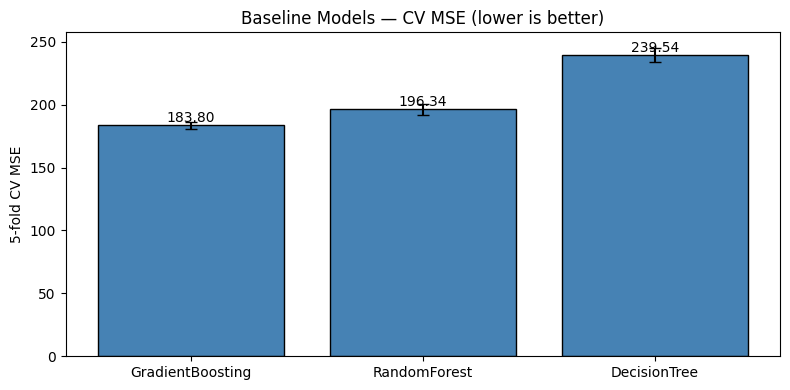

In [12]:
# Quick bar plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results_df['name'], results_df['mse_mean'],
       yerr=results_df['mse_std'], capsize=4, color='steelblue', edgecolor='black')
ax.set_ylabel('5-fold CV MSE')
ax.set_title('Baseline Models — CV MSE (lower is better)')
for i, v in enumerate(results_df['mse_mean']):
    ax.text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.tight_layout(); plt.savefig(OUT_DIR / 'baseline_cv_bar.png', dpi=120); plt.show()

## 6. Refit Best Model on Full Train → Kaggle Submission

In [13]:
best_name = results_df.iloc[0]['name']
best_model_obj = {'DecisionTree': dt_model,
                  'RandomForest': rf_model,
                  'GradientBoosting': gb_model}[best_name]
print(f'Best baseline: {best_name} (CV MSE = {results_df.iloc[0]["mse_mean"]:.3f})')

best_pipe = Pipeline(steps=[('prep', preprocessor), ('model', best_model_obj)])
best_pipe.fit(X, y)
test_pred = np.clip(best_pipe.predict(X_test), 0, 92)
print('Test predictions shape:', test_pred.shape)
print('First 10 preds:', test_pred[:10].round(2))

Best baseline: GradientBoosting (CV MSE = 183.799)


Test predictions shape: (24318,)
First 10 preds: [ 0.09 55.25  6.81 33.61 26.62  0.15  4.74 85.72 74.95 29.5 ]


In [14]:
# Per-model submissions (refit each on full train) — handy to compare on the public LB.
all_models = {'DecisionTree': dt_model, 'RandomForest': rf_model, 'GradientBoosting': gb_model}
for name, model in all_models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', model)])
    pipe.fit(X, y)
    pred = np.clip(pipe.predict(X_test), 0, 92)
    sub = pd.DataFrame({'Property[Q3]_test': test_ids, 'Pred': pred})
    out_path = OUT_DIR / f'submission_baseline_{name}.csv'
    sub.to_csv(out_path, index=False)
    print(f'Saved {out_path.name} | mean={pred.mean():.2f}  zeros={(pred < 0.5).mean()*100:.1f}%')

Saved submission_baseline_DecisionTree.csv | mean=18.12  zeros=30.4%


Saved submission_baseline_RandomForest.csv | mean=18.32  zeros=10.8%


Saved submission_baseline_GradientBoosting.csv | mean=18.22  zeros=20.1%


In [15]:
# Verify submission format
sub = pd.read_csv(OUT_DIR / f'submission_baseline_{best_name}.csv')
print('Header :', list(sub.columns))
print('Rows   :', len(sub))
print('NaNs   :', sub.isna().sum().sum())
print('Range  :', sub['Pred'].min(), '→', sub['Pred'].max())
sub.head()

Header : ['Property[Q3]_test', 'Pred']
Rows   : 24318
NaNs   : 0
Range  : 0.0 → 92.0


,Property[Q3]_test,Pred
0,795,0.088274
1,2515,55.254971
2,2595,6.811977
3,5099,33.611736
4,5107,26.623916


## 7. Permutation Feature Importance (Best Model)
Quick sanity check: do the features we expect to matter (Q2 booking rate, recent window, reviews) actually drive predictions?

In [16]:
# Use a held-out slice (last 20% of rows after shuffling) so we don't pay the
# full CV cost again — this is just a sanity peek.
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.permutation(len(y))
split = int(0.8 * len(y))
tr_idx, va_idx = idx[:split], idx[split:]

best_pipe.fit(X.iloc[tr_idx], y[tr_idx])
perm = permutation_importance(best_pipe, X.iloc[va_idx], y[va_idx],
                              n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE,
                              scoring='neg_mean_squared_error')
imp = pd.DataFrame({
    'feature': X.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=False)
imp.head(25)

,feature,importance,std
27,ReviewsPerMonth,102.440252,2.680716
60,q2_days_R,70.640870,2.435406
32,ResponseRate_missing,35.993872,2.233773
5,NumberofReviews,17.321446,1.014297
130,recent_available,13.688184,1.322695
29,WeeklyDiscount,10.079333,0.897863
134,recent_available_rate,9.264397,1.297669
71,q2_reserved_rate,8.559963,0.847042
129,recent_booked,7.417295,0.999189
133,recent_booking_rate,3.995504,0.867338


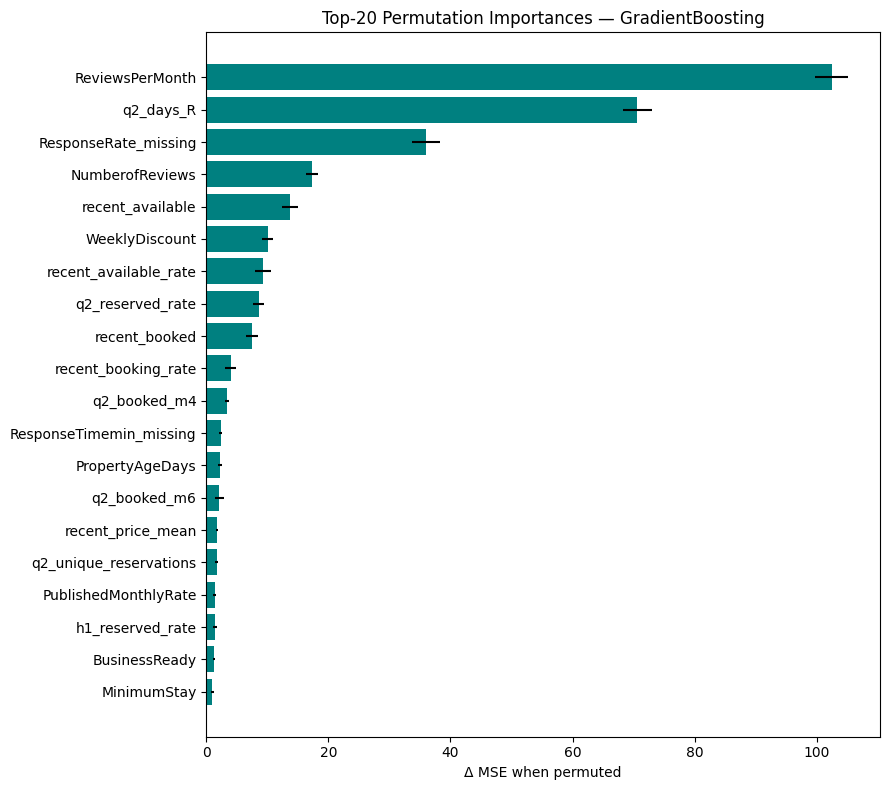

In [17]:
top = imp.head(20)[::-1]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top['feature'], top['importance'], xerr=top['std'], color='teal')
ax.set_title(f'Top-20 Permutation Importances — {best_name}')
ax.set_xlabel('Δ MSE when permuted')
plt.tight_layout(); plt.savefig(OUT_DIR / 'baseline_perm_importance.png', dpi=120); plt.show()

## Summary & Next Step

We now have:
- A reproducible, leakage-free `Pipeline` covering imputation + encoding.
- CV scores for **DecisionTree, RandomForest, GradientBoosting** with consistent splits.
- Out-of-fold predictions saved (for later ensembling).
- Three submission files ready for Kaggle.
- A first read on which engineered features actually move the needle.

### → `04_XGBoost_MLP.ipynb`
Next we'll:
1. Tune **XGBoost** with `RandomizedSearchCV` + early stopping (Module 10-11).
2. Train a **PyTorch MLP** with Adam (Modules 12-13).
3. Compare against baselines and produce a blended final submission.